In [1]:
# 数据处理
import numpy as np
import pandas as pd

# 展示输出
from IPython.display import display

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 模型与评估
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
# 模型
from sklearn.linear_model import LinearRegression, LogisticRegression

# 数据集工具
from sklearn.datasets import make_regression, make_classification

# 评估指标
from sklearn.metrics import mean_squared_error, accuracy_score

In [2]:
# 读取数据（第一行作为列名）
df = pd.read_csv('student_career_success_dataset.csv', header=0)

print('数据形状:', df.shape)
display(df.head())


数据形状: (50000, 29)


,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256


In [3]:
# 根据 Starting_Salary_USD 创建新列：>80000 为 1，否则为 0
df['High_Salary'] = (df['Starting_Salary_USD'] > 90000).astype(int)

print('新列分布：')
display(df['High_Salary'].value_counts())
display(df.head())


新列分布：


High_Salary
0    31438
1    18562
Name: count, dtype: int64

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD,High_Salary
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082,0
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898,1
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256,0


In [4]:
# 2.1 基本信息统计
display(df.describe())

,Age,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,Internships,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,Interview_Score,Employability_Score,Starting_Salary_USD,High_Salary
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,21.262900,81.409640,21.52816,3.106043,7.137160,8.620560,1.715660,3.093940,4.048880,96.045740,8.435780,7.006200,7.175060,77.515400,213.991394,68988.167480,0.371240
std,2.041163,9.709519,6.97481,0.290351,1.507194,2.505408,1.368301,1.660774,1.005719,7.331565,1.387543,1.606802,1.674428,12.579382,26.824224,38480.607679,0.483141
min,18.000000,50.000000,5.00000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,44.000000,3.000000,2.000000,1.000000,17.000000,82.300000,0.000000,0.000000
25%,20.000000,75.000000,17.00000,2.910000,6.000000,7.000000,1.000000,2.000000,3.000000,95.000000,7.000000,6.000000,6.000000,70.000000,197.350000,65229.250000,0.000000
50%,21.000000,82.000000,21.00000,3.110000,7.000000,9.000000,2.000000,3.000000,4.000000,100.000000,9.000000,7.000000,7.000000,78.000000,217.250000,83044.500000,0.000000
75%,22.000000,88.000000,26.00000,3.310000,8.000000,10.000000,3.000000,4.000000,5.000000,100.000000,10.000000,8.000000,8.000000,87.000000,233.600000,96486.250000,1.000000
max,30.000000,100.000000,45.00000,4.000000,10.000000,15.000000,8.000000,10.000000,5.000000,100.000000,10.000000,10.000000,10.000000,100.000000,279.050000,110000.000000,1.000000


In [5]:
# 2.2 检查缺失值
print('缺失值统计：')
display(df.isnull().sum())

缺失值统计：


Student_ID               0
Age                      0
Gender                   0
University_Year          0
Major                    0
Attendance_Percentage    0
Study_Hours_Per_Week     0
CGPA                     0
Academic_Performance     0
Programming_Skill        0
Projects_Completed       0
Certifications           0
Hackathons               0
GitHub_Profile           0
Internships              0
Leadership_Experience    0
LinkedIn_Profile         0
Resume_Score             0
Communication_Skills     0
Teamwork                 0
Problem_Solving          0
English_Proficiency      0
Interview_Score          0
Employability_Score      0
Placement_Status         0
Company_Tier             0
Career_Field             0
Placement_Mode           0
Starting_Salary_USD      0
High_Salary              0
dtype: int64

In [6]:
# 2.3 类别分布（是否平衡）
print('录取情况分布：')
display(df['High_Salary'].value_counts())

录取情况分布：


High_Salary
0    31438
1    18562
Name: count, dtype: int64

In [13]:
# 2.4.1 Scatter plot: exam scores vs admission status
# 过滤掉 Study_Hours_Per_Week、CGPA 或 Starting_Salary_USD 为 0 的样本
df_plot = df[(df['CGPA'] > 0) &
             (df['Study_Hours_Per_Week'] > 0) &
             (df['Attendance_Percentage'] > 0)]
# 注意：用双中括号 [[]] 保持二维，LinearRegression 要求 X 是二维
X = df_plot[['Study_Hours_Per_Week']]
y = df_plot['CGPA']
print(f'过滤前样本数: {len(df)}, 过滤后样本数: {len(df_plot)}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

过滤前样本数: 50000, 过滤后样本数: 50000
X shape: (50000, 1)
y shape: (50000,)


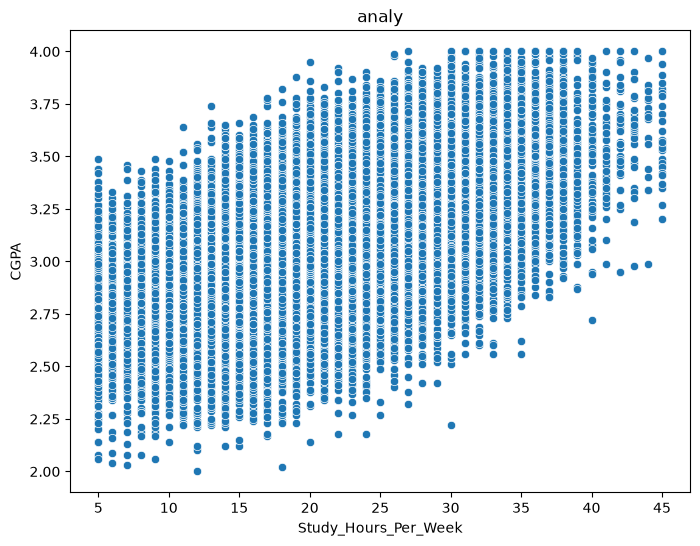

In [14]:
plt.figure(figsize=(8, 6))

# 按录取与否分别绘制散点
sns.scatterplot(
    data=df_plot,
    x='Study_Hours_Per_Week',
    y='CGPA',
)
plt.title('analy')
plt.xlabel('Study_Hours_Per_Week')
plt.ylabel('CGPA')
plt.show()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

print('数据集划分结果：')
display(pd.DataFrame({
    '数据集': ['训练集', '测试集'],
    '样本数': [len(X_train), len(X_test)]
}))

数据集划分结果：


,数据集,样本数
0,训练集,37500
1,测试集,12500


In [16]:
# 2.3 创建并训练线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 输出模型的系数和截距
display(pd.DataFrame({
    '参数': ['斜率 (coef_)', '截距 (intercept_)'],
    '数值': [model.coef_[0], model.intercept_]
}))

,参数,数值
0,斜率 (coef_),0.022255
1,截距 (intercept_),2.626233


In [17]:
# 2.4 预测并评估模型
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print('预测结果示例：')
display(pd.DataFrame({'真实值': y_test[:5], '预测值': y_pred[:5]}))

print(f'\n均方误差 (MSE): {mse:.2f}')

预测结果示例：


,真实值,预测值
11841,2.90,3.115841
19602,2.99,3.049076
45519,3.13,3.004567
25747,3.33,3.382900
42642,3.85,3.382900



均方误差 (MSE): 0.06


In [19]:
# 根据 Starting_Salary_USD 创建新列：>80000 为 1，否则为 0
df['High_CGPA'] = (df['CGPA'] > 3.2).astype(int)

print('新列分布：')
display(df['High_Salary'].value_counts())
display(df.head())
# 2.3 类别分布（是否平衡）
print('高分情况：')
display(df['High_Salary'].value_counts())

新列分布：


High_Salary
0    31438
1    18562
Name: count, dtype: int64

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD,High_Salary,High_CGPA
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082,0,1
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0,0,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898,1,0
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0,0,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256,0,0


高分情况：


High_Salary
0    31438
1    18562
Name: count, dtype: int64

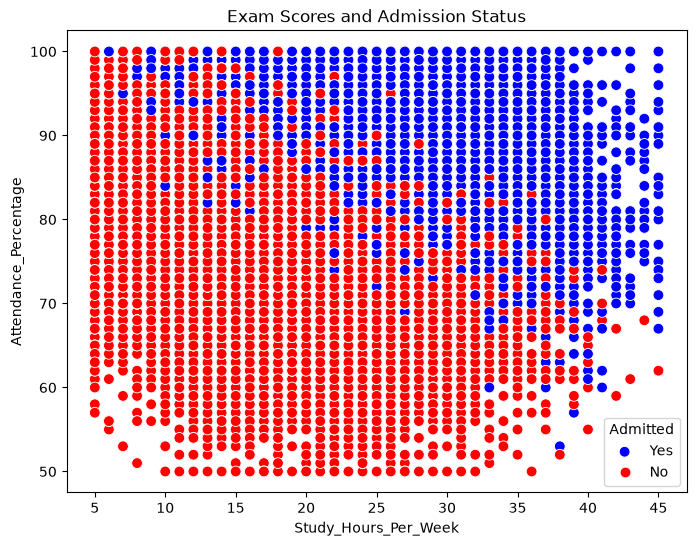

In [21]:
# 2.4.1 Scatter plot: exam scores vs admission status
plt.figure(figsize=(8, 6))

# 按录取与否分别绘制散点
sns.scatterplot(data=df, x='Study_Hours_Per_Week', y='Attendance_Percentage',
                hue='High_CGPA', palette={0: 'red', 1: 'blue'}, s=60)

plt.title('Exam Scores and Admission Status')
plt.xlabel('Study_Hours_Per_Week')
plt.ylabel('Attendance_Percentage')
plt.legend(title='Admitted', labels=['Yes', 'No'])
plt.show()

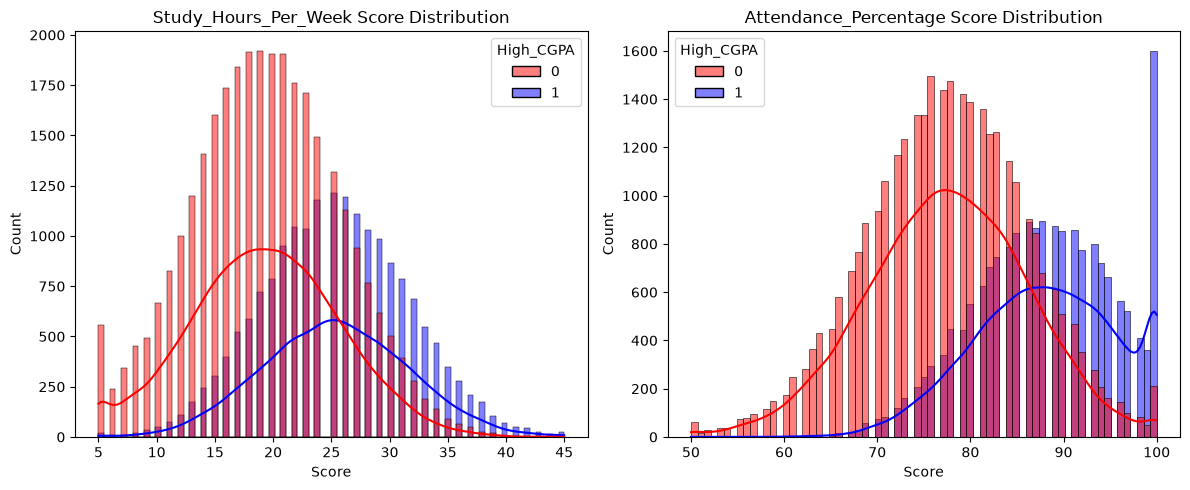

In [22]:
# 2.4.2 Histograms of exam scores (grouped by admission status)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ['Study_Hours_Per_Week', 'Attendance_Percentage']):
    sns.histplot(data=df, x=col, hue='High_CGPA',
                 kde=True, palette={0: 'red', 1: 'blue'}, ax=ax)
    ax.set_title(f'{col} Score Distribution')
    ax.set_xlabel('Score')

plt.tight_layout()
plt.show()

In [23]:
# 3.1 分离特征和标签
X = df[['Study_Hours_Per_Week', 'Attendance_Percentage']]  
y = df['High_CGPA']         

# 3.2 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

print(f'训练集样本数: {len(X_train)}')
print(f'测试集样本数: {len(X_test)}')

训练集样本数: 35000
测试集样本数: 15000


In [24]:
# 3.3 创建并训练逻辑回归模型
clf = LogisticRegression()
clf.fit(X_train, y_train)

print('模型训练完成！')
display(pd.DataFrame({
    '特征': ['Exam1', 'Exam2', '截距'],
    '系数': [clf.coef_[0][0], clf.coef_[0][1], clf.intercept_[0]]
}))

模型训练完成！


,特征,系数
0,Exam1,0.260799
1,Exam2,0.232991
2,截距,-25.735780


In [25]:
# 3.4 在测试集上预测并评估
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# 显式计算精确率、召回率、F1（以"录取"为正类，即 pos_label=1）
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f'准确率 (Accuracy): {acc:.4f}')
print(f'精确率 (Precision): {precision:.4f}')
print(f'召回率 (Recall): {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

print('\n混淆矩阵：')
display(pd.DataFrame(confusion_matrix(y_test, y_pred),
                     index=['实际未录取', '实际录取'],
                     columns=['预测未录取', '预测录取']))

# 用表格汇总各评估指标
display(pd.DataFrame({
    '评估指标': ['准确率 Accuracy', '精确率 Precision', '召回率 Recall', 'F1 Score'],
    '含义': ['预测正确的比例',
            '被预测为录取的样本中真正录取的比例',
            '实际录取的样本中被正确预测的比例',
            '精确率与召回率的调和平均'],
    '数值': [acc, precision, recall, f1]
}))


准确率 (Accuracy): 0.8330
精确率 (Precision): 0.7893
召回率 (Recall): 0.7485
F1 Score: 0.7684

混淆矩阵：


,预测未录取,预测录取
实际未录取,8340,1109
实际录取,1396,4155


,评估指标,含义,数值
0,准确率 Accuracy,预测正确的比例,0.833000
1,精确率 Precision,被预测为录取的样本中真正录取的比例,0.789324
2,召回率 Recall,实际录取的样本中被正确预测的比例,0.748514
3,F1 Score,精确率与召回率的调和平均,0.768377


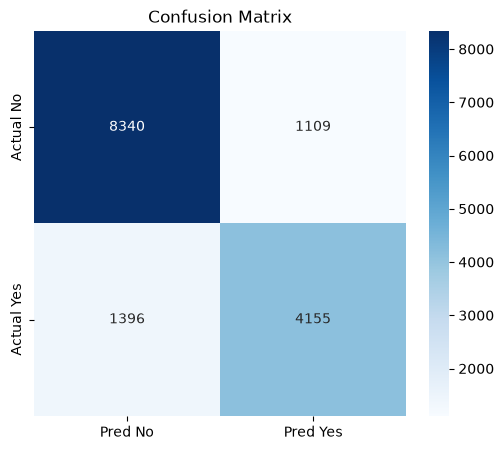

In [26]:
# 3.5 Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.show()


In [27]:
# 3.6 详细的分类报告（精确率、召回率、F1）
print('分类报告：')
print(classification_report(y_test, y_pred, target_names=['未录取', '录取']))


分类报告：
              precision    recall  f1-score   support

         未录取       0.86      0.88      0.87      9449
          录取       0.79      0.75      0.77      5551

    accuracy                           0.83     15000
   macro avg       0.82      0.82      0.82     15000
weighted avg       0.83      0.83      0.83     15000

